# Test FNPE Diagnostics: Pairplot, C2ST, and Diffusion Traces

This notebook tests the newly added diagnostic functions for FNPE:
1. **Pairplot** - 2D marginal posterior visualizations (markovsbi-style)
2. **C2ST** - Classifier Two-Sample Test for posterior quality
3. **Diffusion Traces** - Visualization of the reverse diffusion sampling process

All diagnostics are now modular and can be run independently.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '..')  # Add parent directory to path

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# JAX imports
import jax
import jax.numpy as jnp

# Local imports
from configs.config import ExperimentConfig
from utils.normalization import Normalizer
from utils.plots import (
    plot_pairplot, 
    compute_c2st, 
    plot_c2st_comparison, 
    plot_diffusion_traces
)

# Check devices
print(f"JAX devices: {jax.devices()}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\aritr\anaconda3\envs\sbi_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX devices: [CpuDevice(id=0)]
PyTorch CUDA available: True
Using device: cuda


## 1. Setup FNPE Method

We'll create a minimal FNPE setup to test the diagnostics.

In [3]:
# Create experiment configuration for FNPE
cfg = ExperimentConfig(
    exp_name="test_diagnostics",
    method="fnpe",
    T_seg=300,  # Short sequence for quick testing
    num_simulations=500,  # Small dataset for demo
    fnpe_num_diffusion_steps=200,  # Fewer steps for faster sampling
    fnpe_score_fn_type="fnpe",  # Fast score function
    fnpe_normalize_score=True,
    fnpe_max_obs_len=100,
    random_seed=42,
    no_plots=False,
)

print(f"Method: {cfg.method}")
print(f"T_seg: {cfg.T_seg}")
print(f"Score function: {cfg.fnpe_score_fn_type}")
print(f"Active parameters: {cfg.active_parameters}")

Method: fnpe
T_seg: 300
Score function: fnpe
Active parameters: ('mu', 'cd', 'm')


In [4]:
# Initialize FNPE method
from methods import build_method
from models.models import build_prior

# Build prior first (required by build_method)
prior_phys = build_prior(cfg, device)

# Build method with all required arguments
method = build_method(cfg.method, cfg, prior_phys, device)
print(f"Method type: {type(method).__name__}")
print(f"Task: {type(method.task).__name__}")

Method type: FNPEMethod
Task: NoneType


## 2. Generate Training Data and Train (Quick)

We'll do a quick training run to get a working posterior.

In [5]:
# Build the method (this initializes the task)
# FNPE needs build() to be called before training
D_in = cfg.obs_dim  # 9 observation channels
T_event = cfg.T_seg  # Sequence length

method.build(input_dim=D_in, seq_len=T_event)
print(f"Method built!")
print(f"Task type: {type(method.task).__name__}")

# Generate training data using FNPE's internal data generation
key = jax.random.PRNGKey(cfg.random_seed)
key, key_data = jax.random.split(key)

# Get training data
T_obs = min(50, cfg.T_seg // 2)  # Window size for observations
data = method.task.get_data(key_data, cfg.num_simulations, T_obs)

print(f"Training data shapes:")
print(f"  thetas: {data['thetas'].shape}")
print(f"  xs: {data['xs'].shape}")

[FNPE] JAX devices: [CpuDevice(id=0)]
[FNPE] Default backend: cpu
Method built!
Task type: VehicleDynamicsTask
[FNPE] Running 50 pilot simulations (T=200) for proposal...


Pilot sims: 100%|██████████| 50/50 [00:01<00:00, 41.96it/s]

[FNPE] Proposal pool: 10000 states from 50 trajectories


[FNPE] Sampling 500 initial states from proposal...


Generating data: 100%|██████████| 2/2 [00:01<00:00,  1.38batch/s]


Training data shapes:
  thetas: (500, 3)
  xs: (500, 50, 9)


Starting quick training...
[FNPE] Generating 500 training samples (T=2, window_size=2)...
[FNPE] (Full observation length T_obs=50 will be used at inference)
[FNPE] Using 'pred' proposal (covering full state space)
[FNPE] Running 20 pilot simulations (T=50) for proposal...


Pilot sims: 100%|██████████| 20/20 [00:00<00:00, 40.89it/s]

[FNPE] Proposal pool: 1000 states from 20 trajectories
[FNPE] Sampling 500 initial states from proposal...



Generating data: 100%|██████████| 2/2 [00:01<00:00,  1.45batch/s]

[FNPE] Data shapes: thetas=(500, 3), xs=(500, 2, 9)
[FNPE] Initializing SDE...
[FNPE] Training score network (max 2 epochs, early stop after 20)...


[FNPE] Train/Val split: 450/50 samples
[FNPE] Score network: 84,108 parameters
[FNPE] JIT compiling...
[FNPE] JIT compilation complete.
[FNPE] Validation: 0 batches of 256 samples
[FNPE] Starting training: 2 epochs, 500 steps/epoch


[FNPE] Epoch 1/2: Train=19.652418, Val=34.558720 (best=34.558720, patience=20) *


[FNPE] Epoch 2/2: Train=18.929783, Val=22.812519 (best=22.812519, patience=20) *


[FNPE] Setting up sampler...

Training completed!
Final train loss: 18.9298
Final val loss: 22.8125


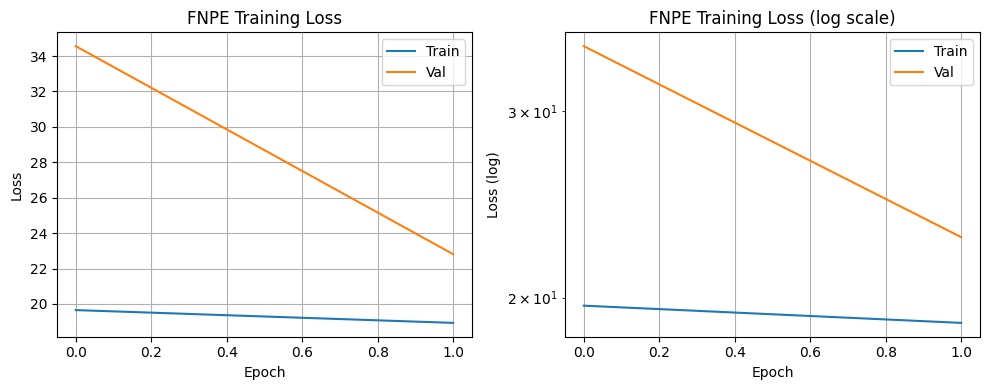

In [6]:
# Quick training using the method's train() function
# This handles all the complexity internally (SDE, score net, optimizer, etc.)

# Override method's internal settings for quick testing
# (cfg values are read at method init time, so we modify method directly)
method.num_epochs = 2  # Very few epochs for quick test
method.steps_per_epoch = 500  # Fewer steps per epoch

print("Starting quick training...")
training_summary = method.train(
    num_simulations=cfg.num_simulations,
    T_obs=T_obs,
)

print(f"\nTraining completed!")
print(f"Final train loss: {training_summary['final_train_loss']:.4f}")
print(f"Final val loss: {training_summary['final_val_loss']:.4f}")

# Plot training curve
train_losses = training_summary['train_loss']
val_losses = training_summary['val_loss']

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FNPE Training Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("FNPE Training Loss (log scale)")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Build Posterior and Normalizer

Create the posterior sampler and normalizer for diagnostics.

In [7]:
# Build normalizer from task stats
norm_stats = method.task.get_normalization_stats()
normalizer = Normalizer(
    obs_mean=torch.tensor(np.array(norm_stats["obs_mean"]), dtype=torch.float32),
    obs_std=torch.tensor(np.array(norm_stats["obs_std"]), dtype=torch.float32),
    ctrl_mean=torch.zeros(4, dtype=torch.float32),
    ctrl_std=torch.ones(4, dtype=torch.float32),
    theta_mean=torch.tensor(np.array(norm_stats["theta_mean"]), dtype=torch.float32),
    theta_std=torch.tensor(np.array(norm_stats["theta_std"]), dtype=torch.float32),
).to(device)

# Build posterior using the method's built-in function
# This uses the trained score network and sampler internally
posterior = method.build_posterior(normalizer=normalizer)

# Get the JAX prior for simulation
jax_prior = method.task.get_prior()
simulator_fn = method.task.get_simulator()

print("Posterior ready!")
print(f"Theta dimension: {method.params is not None}")
print(f"Normalizer device: {normalizer.theta_mean.device}")
print(f"Method has sampler: {method.sampler is not None}")

Posterior ready!
Theta dimension: True
Normalizer device: cuda:0
Method has sampler: True


## 4. Test Pairplot Diagnostic

Generate pairplots showing 2D marginal distributions of the posterior.

In [8]:
# Generate a test observation
key, key_theta, key_sim = jax.random.split(key, 3)
theta_true_jax = jax_prior.sample(key_theta, (1,))[0]
theta_true_np = np.array(theta_true_jax)

simulator_fn = method.task.get_simulator()
x_phys = simulator_fn(key_sim, theta_true_jax, cfg.T_seg)

print(f"True theta: {theta_true_np}")
print(f"Observation shape: {x_phys.shape}")

# Normalize for posterior input
x_phys_torch = torch.tensor(np.array(x_phys), dtype=torch.float32).to(device)
if x_phys_torch.ndim == 2:
    x_phys_torch = x_phys_torch.unsqueeze(0)
x_norm = (x_phys_torch - normalizer.obs_mean) / (normalizer.obs_std + normalizer.eps)

print(f"Normalized obs shape: {x_norm.shape}")

True theta: [9.164864e-01 9.756047e-02 1.941026e+03]
Observation shape: (300, 9)
Normalized obs shape: torch.Size([1, 300, 9])


In [9]:
# Sample from posterior
num_samples = 500
print(f"Sampling {num_samples} posterior samples...")

theta_post_norm = posterior.sample((num_samples,), x=x_norm)
theta_post_phys = normalizer.unnormalize_theta(theta_post_norm)
theta_post_np = theta_post_phys.detach().cpu().numpy()

print(f"Posterior samples shape: {theta_post_np.shape}")
print(f"Sample mean: {theta_post_np.mean(axis=0)}")
print(f"True theta:  {theta_true_np}")

Sampling 500 posterior samples...
Posterior samples shape: (500, 3)
Sample mean: [9.7589189e-01 3.5347474e-01 2.0369895e+03]
True theta:  [9.164864e-01 9.756047e-02 1.941026e+03]


In [10]:
# Test plot_pairplot function
fig_dir = Path("../experiments/test_diagnostics/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

param_names = list(cfg.active_parameters)

pairplot_path = fig_dir / "test_pairplot.png"
plot_pairplot(
    samples=theta_post_np,
    out_path=pairplot_path,
    theta_true=theta_true_np,
    param_names=param_names,
    title="FNPE Posterior Pairplot (Test)"
)
print(f"Pairplot saved to: {pairplot_path}")

c:\Users\aritr\Documents\thesis-sbi-aritra\code\notebooks\..\utils\plots.py:615: UserWarning: offdiag is deprecated, use upper or lower instead.
  fig, axes = sbi_pairplot(


[plots] Saved pairplot to ..\experiments\test_diagnostics\figures\test_pairplot.png
Pairplot saved to: ..\experiments\test_diagnostics\figures\test_pairplot.png


## 5. Test C2ST Diagnostic

Compute C2ST comparing posterior to prior samples.

- C2ST ≈ 0.5 means posterior and prior are indistinguishable (uninformative posterior)
- C2ST > 0.5 means posterior is different from prior (expected behavior)
- C2ST ≈ 1.0 means perfectly distinguishable (may indicate overfitting or data mismatch)

In [11]:
# Sample from prior for comparison
prior_torch = torch.distributions.Uniform(
    low=torch.tensor([cfg.prior_low_mu, cfg.prior_low_cd, cfg.prior_low_m]),
    high=torch.tensor([cfg.prior_high_mu, cfg.prior_high_cd, cfg.prior_high_m]),
)
prior_samples = prior_torch.sample((num_samples,)).numpy()

print(f"Prior samples shape: {prior_samples.shape}")
print(f"Prior mean: {prior_samples.mean(axis=0)}")

Prior samples shape: (500, 3)
Prior mean: [1.0101174e+00 3.2048351e-01 1.9468473e+03]


In [12]:
# Test compute_c2st function
c2st_val = compute_c2st(theta_post_np, prior_samples)
print(f"C2ST(posterior, prior) = {c2st_val:.4f}")

if c2st_val < 0.55:
    print("⚠️  C2ST close to 0.5 - posterior may be uninformative")
elif c2st_val > 0.95:
    print("⚠️  C2ST close to 1.0 - posterior very different from prior")
else:
    print("✓  C2ST in reasonable range - posterior is informative")

C2ST(posterior, prior) = 0.6940
✓  C2ST in reasonable range - posterior is informative


In [13]:
# Test with multiple examples
c2st_results = {}
num_examples = 3

for ex_idx in range(num_examples):
    key, key_theta, key_sim = jax.random.split(key, 3)
    theta_true_ex = jax_prior.sample(key_theta, (1,))[0]
    x_ex = simulator_fn(key_sim, theta_true_ex, cfg.T_seg)
    
    # Normalize
    x_ex_torch = torch.tensor(np.array(x_ex), dtype=torch.float32).to(device)
    if x_ex_torch.ndim == 2:
        x_ex_torch = x_ex_torch.unsqueeze(0)
    x_ex_norm = (x_ex_torch - normalizer.obs_mean) / (normalizer.obs_std + normalizer.eps)
    
    # Sample
    post_samples_norm = posterior.sample((num_samples,), x=x_ex_norm)
    post_samples_phys = normalizer.unnormalize_theta(post_samples_norm).detach().cpu().numpy()
    
    # C2ST
    c2st_val = compute_c2st(post_samples_phys, prior_samples)
    c2st_results[f"c2st_prior_ex{ex_idx}"] = c2st_val
    print(f"Example {ex_idx+1}: C2ST = {c2st_val:.4f}")

# Plot comparison
c2st_path = fig_dir / "test_c2st_comparison.png"
plot_c2st_comparison(c2st_results, c2st_path, title="C2ST: Posterior vs Prior")
print(f"C2ST plot saved to: {c2st_path}")

Example 1: C2ST = 0.6830
Example 2: C2ST = 0.6920
Example 3: C2ST = 0.6870
[plots] Saved C2ST comparison to ..\experiments\test_diagnostics\figures\test_c2st_comparison.png
C2ST plot saved to: ..\experiments\test_diagnostics\figures\test_c2st_comparison.png


## 6. Test Diffusion Traces Diagnostic

Visualize the reverse diffusion process showing how samples evolve from noise to the posterior.

In [14]:
# Test sample_with_traces method
print("Sampling with traces...")
num_traces = 20

traces = posterior.sample_with_traces(
    sample_shape=(num_traces,),
    x=x_norm,
    return_physical=True,
)

print(f"Traces shape: {traces.shape}")
print(f"Expected: (num_traces, num_diffusion_steps, d_theta)")
print(f"Final samples (last step): {traces[:5, -1, :]}")

Sampling with traces...
Traces shape: (20, 500, 3)
Expected: (num_traces, num_diffusion_steps, d_theta)
Final samples (last step): [[1.0497062e+00 2.3139107e-01 2.1333984e+03]
 [1.0093728e+00 4.4830772e-01 2.1266233e+03]
 [7.9109901e-01 5.5093634e-01 2.0057906e+03]
 [1.0291777e+00 4.1786364e-01 2.0242325e+03]
 [9.0616214e-01 4.4366518e-01 1.9892843e+03]]


In [15]:
# Test plot_diffusion_traces function
traces_path = fig_dir / "test_diffusion_traces.png"

plot_diffusion_traces(
    traces=traces,
    out_path=traces_path,
    theta_true=theta_true_np,
    param_names=param_names,
    title="FNPE Diffusion Traces (Test)"
)
print(f"Diffusion traces saved to: {traces_path}")

[plots] Saved diffusion traces to ..\experiments\test_diagnostics\figures\test_diffusion_traces.png
Diffusion traces saved to: ..\experiments\test_diagnostics\figures\test_diffusion_traces.png


## 7. Test Full Diagnostic Pipeline (Modular Functions)

Test the modular `run_pairplot_diagnostic` and `run_c2st_diagnostic` functions from unified_experiment.py

In [17]:
from inference.unified_experiment import (
    run_pairplot_diagnostic,
    run_c2st_diagnostic,
    run_diffusion_traces_diagnostic,
)
from models.models import build_prior

# Build torch prior for diagnostics
prior_phys = build_prior(cfg, device)

# Simple simulator wrapper
def simulator_wrapper(theta):
    """Wrapper to simulate from torch theta."""
    if isinstance(theta, torch.Tensor):
        theta_np = theta.detach().cpu().numpy()
    else:
        theta_np = np.asarray(theta)
    
    theta_jax = jnp.asarray(theta_np.squeeze())
    key_sim = jax.random.PRNGKey(np.random.randint(0, 10000))
    x = simulator_fn(key_sim, theta_jax, cfg.T_seg)
    return torch.tensor(np.array(x), dtype=torch.float32)

print("Testing modular diagnostic functions...")

Testing modular diagnostic functions...


In [18]:
# Test run_pairplot_diagnostic (modular)
print("\n--- Testing run_pairplot_diagnostic ---")
run_pairplot_diagnostic(
    cfg=cfg,
    fig_dir=fig_dir,
    prior=prior_phys,
    posterior=posterior,
    simulator=simulator_wrapper,
    normalizer=normalizer,
    device=device,
    num_posterior_samples=200,  # Reduced for quick test
    num_examples=2,
    method=method,
)
print("✓ Pairplot diagnostic completed!")


--- Testing run_pairplot_diagnostic ---
[PAIRPLOT] Generating pairplot visualizations...
[PAIRPLOT] Example 1/2 (FNPE)


c:\Users\aritr\Documents\thesis-sbi-aritra\code\notebooks\..\utils\plots.py:615: UserWarning: offdiag is deprecated, use upper or lower instead.
  fig, axes = sbi_pairplot(


[plots] Saved pairplot to ..\experiments\test_diagnostics\figures\pairplot_ex0.png
[PAIRPLOT] Example 2/2 (FNPE)
[plots] Saved pairplot to ..\experiments\test_diagnostics\figures\pairplot_ex1.png
✓ Pairplot diagnostic completed!


In [19]:
# Test run_c2st_diagnostic (modular)
print("\n--- Testing run_c2st_diagnostic ---")
c2st_results = run_c2st_diagnostic(
    cfg=cfg,
    fig_dir=fig_dir,
    prior=prior_phys,
    posterior=posterior,
    simulator=simulator_wrapper,
    normalizer=normalizer,
    device=device,
    num_posterior_samples=200,
    num_examples=2,
    method=method,
)
print(f"✓ C2ST results: {c2st_results}")


--- Testing run_c2st_diagnostic ---
[C2ST] Computing C2ST diagnostics...
[C2ST] Example 1/2 (FNPE)
[C2ST] Example 1: C2ST(posterior, prior) = 0.6875
[C2ST] Example 2/2 (FNPE)
[C2ST] Example 2: C2ST(posterior, prior) = 0.6900
[plots] Saved C2ST comparison to ..\experiments\test_diagnostics\figures\c2st_comparison.png
✓ C2ST results: {'c2st_prior_ex0': 0.6874999999999999, 'c2st_prior_ex1': 0.6900000000000001}


In [20]:
# Test run_diffusion_traces_diagnostic (modular)
print("\n--- Testing run_diffusion_traces_diagnostic ---")
run_diffusion_traces_diagnostic(
    cfg=cfg,
    fig_dir=fig_dir,
    posterior=posterior,
    prior=prior_phys,
    simulator=simulator_wrapper,
    normalizer=normalizer,
    device=device,
    num_traces=30,
    num_examples=1,
    method=method,
)
print("✓ Diffusion traces diagnostic completed!")


--- Testing run_diffusion_traces_diagnostic ---
[TRACES] Generating diffusion trace plots...
[TRACES] Example 1/1
[plots] Saved diffusion traces to ..\experiments\test_diagnostics\figures\diffusion_traces_ex0.png
✓ Diffusion traces diagnostic completed!


## 8. Summary

All new diagnostic functions have been tested:

| Function | Purpose | Output |
|----------|---------|--------|
| `plot_pairplot()` | 2D marginal posterior visualization | PNG figure |
| `compute_c2st()` | Classifier Two-Sample Test | Float (0.5-1.0) |
| `plot_c2st_comparison()` | Bar chart of C2ST values | PNG figure |
| `plot_diffusion_traces()` | Reverse diffusion visualization | PNG figure |
| `FNPEPosterior.sample_with_traces()` | Get full diffusion trajectories | Array (N, steps, d) |
| `run_pairplot_diagnostic()` | Modular pairplot generation | Figures |
| `run_c2st_diagnostic()` | Modular C2ST computation | Dict + figures |
| `run_diffusion_traces_diagnostic()` | Modular trace visualization | Figures |

These diagnostics match the markovsbi notebook style and are fully integrated into the unified experiment pipeline.

In [21]:
# List generated files
print("Generated diagnostic files:")
for f in sorted(fig_dir.glob("*.png")):
    print(f"  - {f.name}")

Generated diagnostic files:
  - c2st_comparison.png
  - diffusion_traces_ex0.png
  - pairplot_ex0.png
  - pairplot_ex1.png
  - test_c2st_comparison.png
  - test_diffusion_traces.png
  - test_pairplot.png
